## Imports

In [1]:
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_tabular
import lightning as L
import torch
import torch.nn as nn
import torchmetrics
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from pnpl.datasets import LibriBrainSpeech
from torch.utils.data import DataLoader
import lime_explanation
import lime_visualization

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Speech detection model

In [2]:
class SpeechModel(nn.Module):
    """
    Parameters:
        input_dim (int): Number of channels/features in the input tensor (usually SENSORS_SPEECH_MASK)
        model_dim (int): Dimensionality for the intermediate model representation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        lstm_layers (int, optional): Number of layers in the LSTM module.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM; otherwise, a unidirectional LSTM.
        batch_norm (bool, optional): Indicates whether to use batch normalization.

    """
    def __init__(self, input_dim, model_dim, dropout_rate=0.3, lstm_layers = 1, bi_directional = False, batch_norm=False):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=model_dim,
            kernel_size=3,
            padding=1,
        )
        self.lstm_layers = lstm_layers
        self.batch_norm = nn.BatchNorm1d(num_features=model_dim) if batch_norm else nn.Identity()
        self.conv_dropout = nn.Dropout(p=dropout_rate)
        self.lstm = nn.LSTM(
            input_size=model_dim,
            hidden_size=model_dim,
            num_layers=self.lstm_layers,
            dropout=dropout_rate,
            batch_first=True,
            bidirectional=bi_directional
        )
        self.lstm_dropout = nn.Dropout(p=dropout_rate)
        self.speech_classifier = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.conv_dropout(x)
        # LSTM expects (batch, seq_len, input_size)
        output, (h_n, c_n) = self.lstm(x.permute(0, 2, 1))
        last_layer_h_n = h_n
        if self.lstm_layers > 1:
            # handle more than one layer
            last_layer_h_n = h_n[-1, :, :]
            last_layer_h_n = last_layer_h_n.unsqueeze(0)
        output = self.lstm_dropout(last_layer_h_n)
        output = output.flatten(start_dim=0, end_dim=1)
        x = self.speech_classifier(output)
        return x

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.sigmoid(logits)
        class_probs = torch.zeros((x.shape[0], 2))
        for i in range(x.shape[0]):
            class_probs[i, 0] = probs[i]
            class_probs[i, 1] = 1-probs[i]
        return class_probs


In [3]:
class SpeechClassifier(L.LightningModule):
    """
    Parameters:
        input_dim (int): Number of input channels/features. This is passed to the underlying SpeechModel.
        model_dim (int): Dimensionality of the intermediate model representation.
        learning_rate (float, optional): Learning rate for the optimizer.
        weight_decay (float, optional): Weight decay for the optimizer.
        batch_size (int, optional): Batch size used during training and evaluation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        smoothing (float, optional): Label smoothing factor applied in the BCEWithLogits loss.
        pos_weight (float, optional): Weight for the positive class in the BCEWithLogits loss.
        batch_norm (bool, optional): Indicates whether to use batch normalization.
        lstm_layers (int, optional): Number of layers in the LSTM module within the SpeechModel.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM in the SpeechModel; otherwise, uses a unidirectional LSTM.
    """

    def __init__(self, input_dim, model_dim, learning_rate=1e-3, weight_decay=0.01, batch_size=32, dropout_rate=0.3, smoothing=0.1, pos_weight = 1.0 , batch_norm = False, lstm_layers = 1, bi_directional = False):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.model = SpeechModel(input_dim, model_dim, dropout_rate=dropout_rate, lstm_layers=lstm_layers, bi_directional=bi_directional, batch_norm=batch_norm)

        self.loss_fn = BCEWithLogitsLossWithSmoothing(smoothing=smoothing, pos_weight = pos_weight)

        self.val_step_outputs = []
        self.test_step_outputs = {}


    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.sigmoid(logits)
        class_probs = torch.zeros((x.shape[0], 2))
        for i in range(x.shape[0]):
            class_probs[i, 0] = probs[i]
            class_probs[i, 1] = 1-probs[i]
        return class_probs

    def _shared_eval_step(self, batch, stage):
        x = batch[0]
        y = batch[1] # (batch, seq_len)

        logits = self(x)
        loss = self.loss_fn(logits, y.unsqueeze(1).float())
        probs = torch.sigmoid(logits)
        y_probs = probs.detach().cpu()

        y_true = batch[1].detach().cpu()
        meg = x.detach().cpu()

        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, batch_size=self.batch_size)
        return loss


    def training_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "train")


    def validation_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "val")


    def test_step(self, batch, batch_idx):
        x = batch[0]
        y = batch[1]  # (batch, seq_len)

        # ugly, taking care of only one label
        if len(y.shape) != 1:
            y = y.flatten(start_dim=0, end_dim=1).view(-1, 1)  # (batch, seq_len) -> (batch * seq_len, 1)
        else:
            y = y.unsqueeze(1)

        logits = self(x)
        loss = self.loss_fn(logits, y.float())
        probs = torch.sigmoid(logits)

        # Append data to the defaultdict
        # Ensure keys exist before appending
        if "y_probs" not in self.test_step_outputs:
            self.test_step_outputs["y_probs"] = []
        if "y_true" not in self.test_step_outputs:
            self.test_step_outputs["y_true"] = []
        if "meg" not in self.test_step_outputs:
            self.test_step_outputs["meg"] = []

        # Append data
        if y.shape[-1] != 1:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], x.shape[-1]).cpu())  # (batch, seq_len)
        else:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], 1).cpu())  # (batch, seq_len)

        self.test_step_outputs["y_true"].extend(batch[1].detach().cpu())  # (batch, seq_len)
        self.test_step_outputs["meg"].extend(x.detach().cpu())  # MEG data (batch, channels, seq_len)

        return self._shared_eval_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        return optimizer


class BCEWithLogitsLossWithSmoothing(nn.Module):
    def __init__(self, smoothing=0.1, pos_weight = 1.0):
        """
        Binary Cross-Entropy Loss with Deterministic Label Smoothing.

        Parameters:
            smoothing (float): Smoothing factor. Must be between 0 and 1.
            pos_weight (float): Weight for the positive class.
        """
        super().__init__()
        self.smoothing = smoothing
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))

    def forward(self, logits, target):
        target = target.float()  # Ensure target is a float tensor
        target_smoothed = target * (1 - self.smoothing) + self.smoothing * 0.5
        return self.bce_loss(logits, target_smoothed)

## Load model

In [4]:
# Setup checkpoint path
checkpoint_path = "speech_model.ckpt"

# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

# Load the SpeechClassifier model from checkpoint
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]
model = SpeechClassifier(
    input_dim=len(SENSORS_SPEECH_MASK),
    model_dim=100,
    learning_rate=1e-3,
    dropout_rate=0.5,
    lstm_layers=2,
    weight_decay=0.01,
    batch_norm=False,
    bi_directional=False
)

# Initialize trainer and test loaded model
trainer = L.Trainer(devices="auto")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Load data

In [5]:
# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

num_workers = 2 if in_colab else 0

# train on one session
train_run_keys = [("0","1","Sherlock7","1")]
train_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=train_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=False, num_workers=num_workers)

# val on one session
val_run_keys = [("0","2","Sherlock7","1")]
val_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=val_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=num_workers)

In [6]:
# These are the sensors we identified as being particularly useful
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]

class FilteredDataset(torch.utils.data.Dataset):
    """
    Parameters:
        dataset: LibriBrain dataset.
        limit_samples (int, optional): If provided, limits the length of the dataset to this
                          number of samples.
        speech_silence_only (bool, optional): If True, only includes segments that are either
                          purely speech or purely silence (with additional balancing).
        apply_sensors_speech_mask (bool, optional): If True, applies a fixed sensor mask to the sensor
                          data in each sample.
    """
    def __init__(self,
                 dataset,
                 limit_samples=None,
                 disable=False,
                 apply_sensors_speech_mask=True):
        self.dataset = dataset
        self.limit_samples = limit_samples
        self.apply_sensors_speech_mask = apply_sensors_speech_mask

        # These are the sensors we identified:
        self.sensors_speech_mask = SENSORS_SPEECH_MASK

        self.balanced_indices = list(range(len(dataset.samples)))
        # Shuffle the indices
        self.balanced_indices = random.sample(self.balanced_indices, len(self.balanced_indices))

    def __len__(self):
        """Returns the number of samples in the filtered dataset."""
        if self.limit_samples is not None:
            return self.limit_samples
        return len(self.balanced_indices)

    def __getitem__(self, index):
        # Map index to the original dataset using balanced indices
        original_idx = self.balanced_indices[index]
        if self.apply_sensors_speech_mask:
            sensors = self.dataset[original_idx][0][self.sensors_speech_mask]
        else:
            sensors = self.dataset[original_idx][0][:]
        label_from_the_middle_idx = self.dataset[original_idx][1].shape[0] // 2
        return [sensors, self.dataset[original_idx][1][label_from_the_middle_idx]]


# Conditionally set num_workers to avoid multiprocessing issues (try increasing if performance is problematic)
num_workers = 2 if in_colab else 0

train_data_filtered = FilteredDataset(train_data)
train_loader_filtered = DataLoader(train_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

val_data_filtered = FilteredDataset(val_data)
val_loader_filtered = DataLoader(val_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

## Get first batch for testing

In [7]:
first_batch = next(iter(train_loader_filtered))
inputs, labels = first_batch
print(inputs.shape, labels.shape)

torch.Size([32, 23, 200]) torch.Size([32])


## Train

In [8]:
# training
trainer = L.Trainer(
    devices="auto",
    max_epochs=5,
    enable_checkpointing=True
)
trainer.fit(model, train_loader_filtered, val_loader_filtered)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                           | Params | Mode 
-------------------------------------------------------------------
0 | model   | SpeechModel                    | 168 K  | train
1 | loss_fn | BCEWithLogitsLossWithSmoothing | 0      | train
-------------------------------------------------------------------
168 K     Trainable params
0         Non-trainable params
168 K     Total params
0.675     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


## Lime for time series

#### Segment signal

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_64700/4275072614.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seq = np.array(inputs[0])


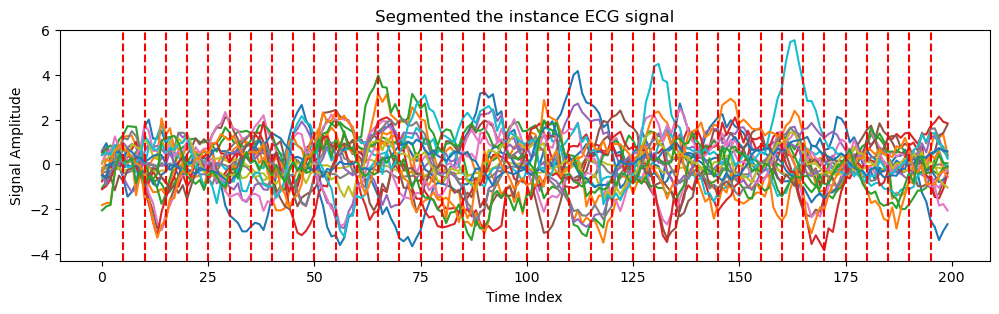

In [9]:
seq = np.array(inputs[0])

# Segmentation using the fixed number of slices
num_slices = 40 
slice_width = lime_explanation.segment_ecg_signal(seq, num_slices)

# plot the segmented ECG signal
lime_visualization.plot_segmented_ecg(seq, slice_width)

#### Generate random perturbations

In [10]:
# Perturbation
num_perturbations = 150
random_perturbations = lime_explanation.generate_random_perturbations(num_perturbations, num_slices)

# Example output
print("The shape of random_perturbations array (num_perturbations, num_slices):", random_perturbations.shape)
print("Example Perturbation:", random_perturbations[-1])


The shape of random_perturbations array (num_perturbations, num_slices): (150, 40)
Example Perturbation: [0 1 0 1 0 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 0 0 0 1 1
 1 0 0]


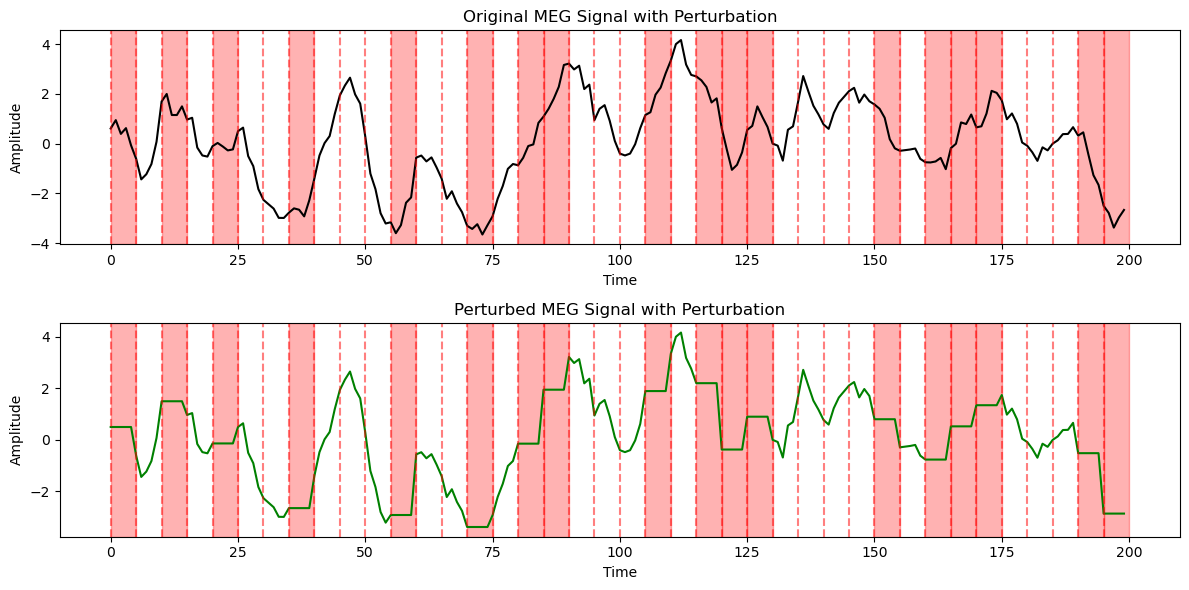

In [11]:
# Apply the Perturbation to the ECG signal and Display

# Choose the perturbation function
perturb_function = lime_explanation.perturb_mean  

# Apply a random perturbation to the ECG signal
perturbed_ecg_example = lime_explanation.apply_perturbation_to_ecg(seq, random_perturbations[-1], num_slices, perturb_function)

# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
lime_visualization.plot_perturbed_ecg(seq[0], perturbed_ecg_example[0], random_perturbations[-1], num_slices, title='MEG Signal with Perturbation')


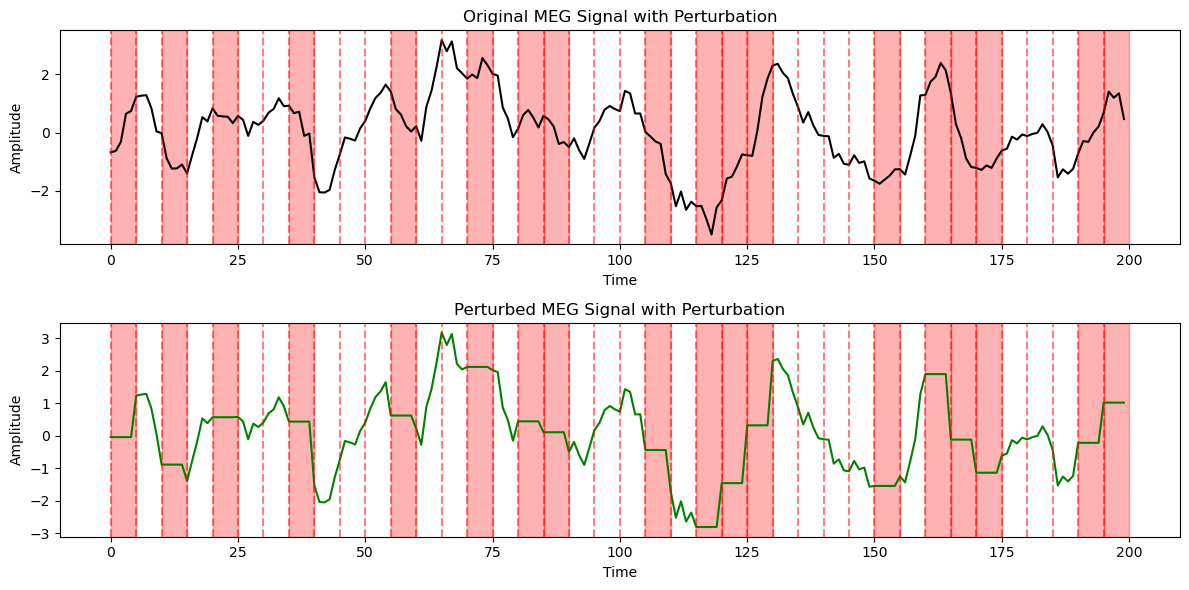

In [12]:
# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
lime_visualization.plot_perturbed_ecg(seq[1], perturbed_ecg_example[1], random_perturbations[-1], num_slices, title='MEG Signal with Perturbation')

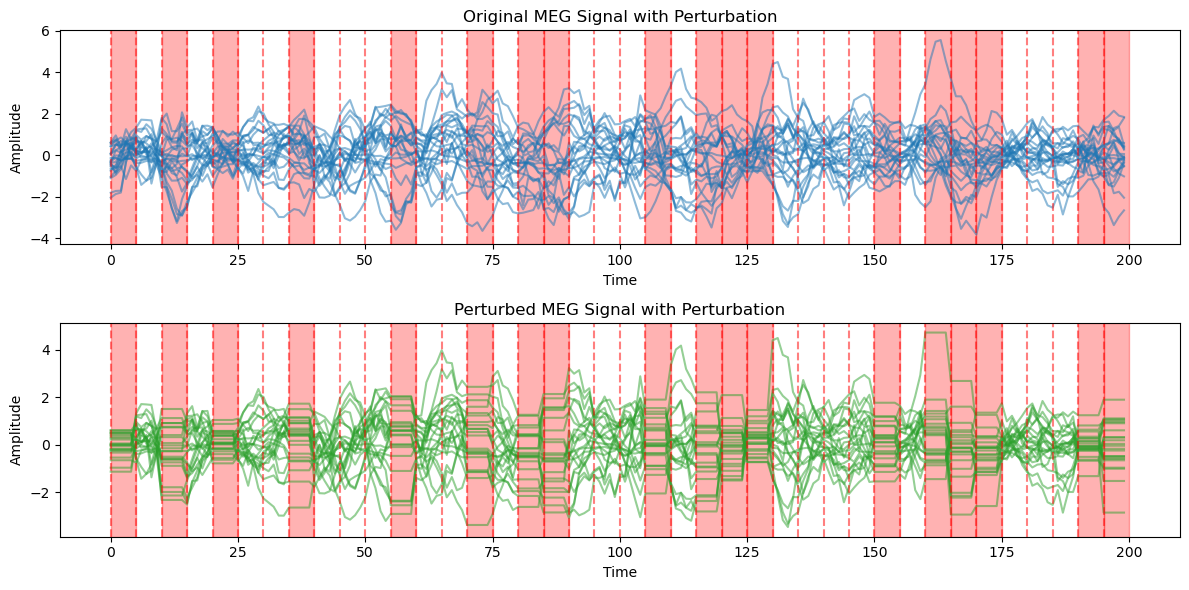

In [ ]:
# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
perturbed_signal = lime_explanation.apply_perturbation_to_ecg(seq, random_perturbations[-1], num_slices, perturb_function)
lime_visualization.plot_perturbed_ecg_all_channels(seq, perturbed_signal, random_perturbations[-1], num_slices, title='MEG Signal with Perturbation')

#### Calculate class probabilities for each perturbed signal

In [17]:
## Predict the class probabilities using the trained ECG classifier
perturbation_predictions = lime_explanation.predict_perturbations(model, seq, random_perturbations, num_slices, lime_explanation.perturb_mean)
print("Shape of perturbation_predictions:", perturbation_predictions.shape)

[W1203 11:47:32.360004000 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


Shape of perturbation_predictions: (150, 1, 2)


#### Calculate distance from perturbed signal to original signal, and use as weights for interpretable model

In [18]:
# Calculate cosine distances between each perturbation and the original ECG signal representation
cosine_distances = lime_explanation.calculate_cosine_distances(random_perturbations, num_slices)
print("Shape of Cosine Distances Array:", cosine_distances.shape)

Shape of Cosine Distances Array: (150,)


In [19]:
#Applying a Kernel Function to Compute Weights
kernel_width = 0.25  # This can be adjusted based on your specific needs
weights = lime_explanation.calculate_weights_from_distances(cosine_distances, kernel_width)

# Now we have the weights for each perturbation for further analysis
print("Shape of Weights Array:", weights.shape)

Shape of Weights Array: (150,)


#### Train an interpretable model (linear regression) to predict class probabilities from perturbed signal
- segment-wise coefficients represent importance to the model's prediction

In [20]:
# Constructing the Explainable Model for ECG Signals
segment_importance_coefficients = lime_explanation.fit_explainable_model(perturbation_predictions, random_perturbations, weights, target_class=1)

# The importance coefficients for each segment
print("Segment Importance Coefficients:", segment_importance_coefficients)


Segment Importance Coefficients: [-0.00488991 -0.00070016  0.00486406  0.00623733  0.00949088 -0.00465444
 -0.00504955 -0.0026789   0.00081529 -0.0066376  -0.01018005 -0.00342815
  0.00160341  0.01836677 -0.00732712 -0.00660539  0.0080662   0.00229427
  0.00345358  0.00758554  0.00132658  0.00443669  0.01409392 -0.00466016
 -0.0016202   0.00750368  0.00202534  0.01037183 -0.01402208 -0.00028117
  0.01466367 -0.01526608  0.01071615  0.00245733  0.00743189 -0.00107561
  0.00326875 -0.00194219  0.00951053 -0.00769114]


#### Identify most important segments and visualize

In [21]:
# Isolating Influential Signal Segments
number_of_top_features = 5
top_influential_segments = lime_explanation.identify_top_influential_segments(segment_importance_coefficients, number_of_top_features)

# The indices of the top influential segments
print("Top Influential Signal Segments:", top_influential_segments)

Top Influential Signal Segments: [28 22 30 31 13]


/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


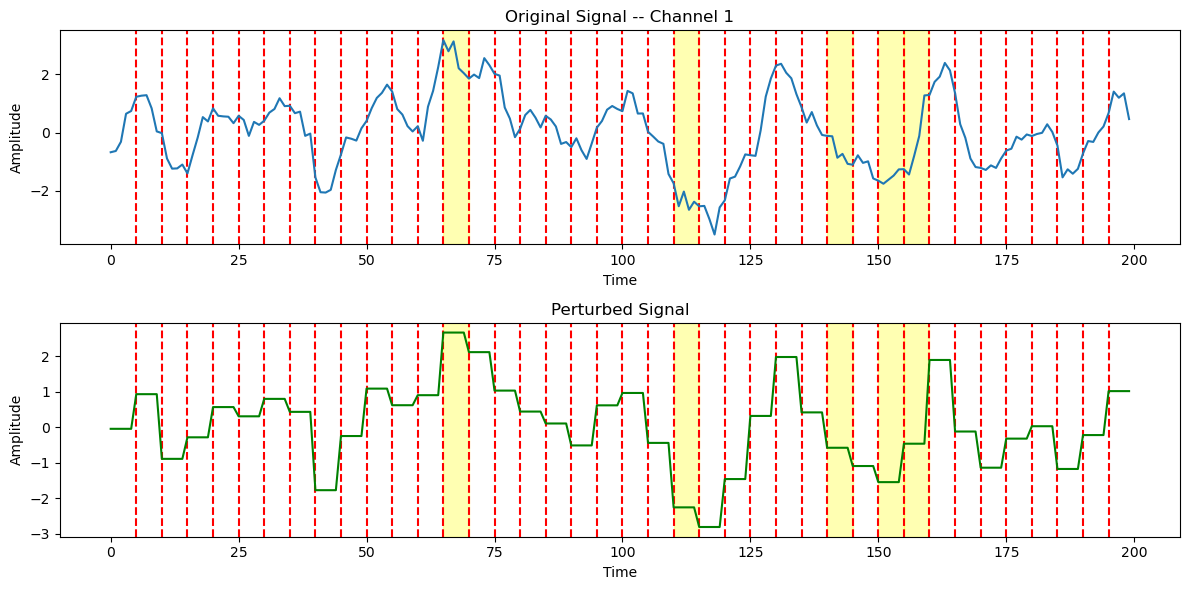

In [22]:
lime_visualization.visualize_lime_explanation(seq, top_influential_segments, num_slices, perturb_function=lime_explanation.perturb_mean, channel=1)

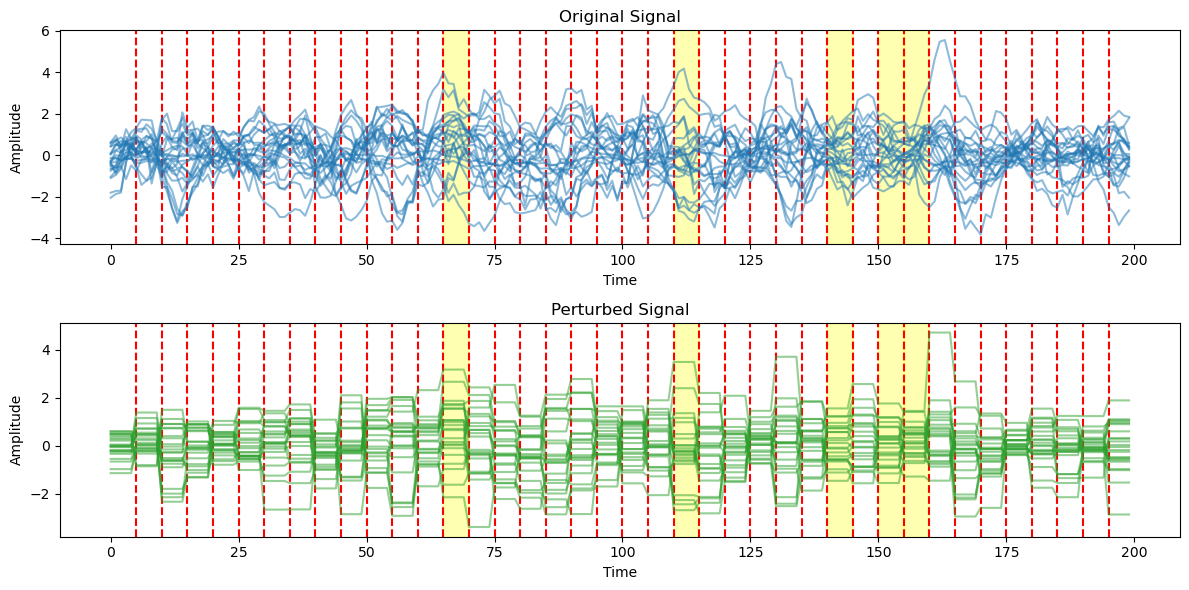

In [ ]:
lime_visualization.visualize_lime_explanation_all_channels(seq, top_influential_segments, num_slices)

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


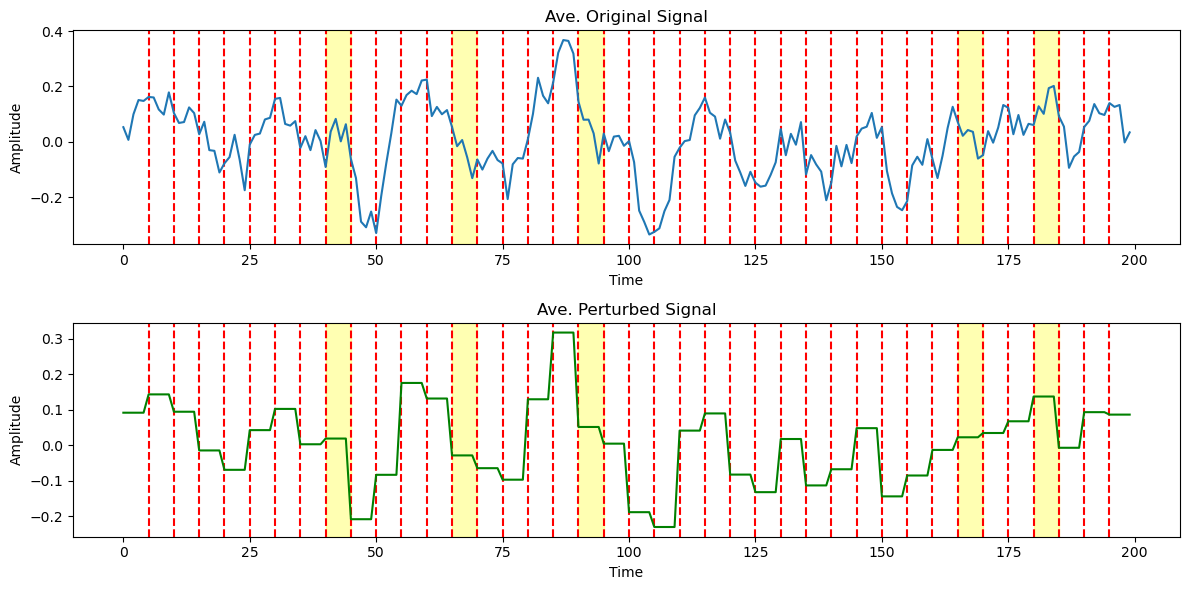

In [65]:
lime_visualization.visualize_ave_lime_explanation(seq, top_influential_segments, num_slices, perturb_function=lime_explanation.perturb_mean)